# **Capítulo 3: Datos Estructurados.  Caso de Estudio 1: COVID-19**

```
Libro: Investigación en Ciencia de Datos
```

**Autora:** Dora María Ballesteros
Universidad Militar Nueva Granada (UMNG)

---


### Material complementario del libro

Este notebook acompaña el **Capítulo 3** del libro y desarrolla el **Caso de Estudio 1: COVID-19**, incluyendo los ejemplos, análisis y experimentos presentados a lo largo del capítulo.

Se recomienda seguir el mismo orden del libro para obtener el máximo provecho de las actividades propuestas.




# **EDA:  ANÁLISIS EXPLORATORIO DE LOS DATOS DEL DATASET CONVID-19**

**0. LECTURA  DEL DATASET COVID-19 DE BOGOTÁ**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
data = pd.read_csv('/content/covid_2020_mayo.csv', encoding = "ISO-8859-1")
data_copy=data.copy()

**1. PRE-VISUALIZACIÓN DEL DATASET**

In [ ]:
registro=len(data)
print(registro)
data.head(registro)

3824


,Fecha de diagnóstico,Ciudad de residencia,Localidad de residencia,Edad,Sexo,Tipo de caso,Ubicación,Estado
0,10/04/2020,Bogotá,Usaquén,19,F,Importado,Casa,Recuperado
1,10/04/2020,Bogotá,Engativá,22,F,Importado,Casa,Recuperado
2,10/04/2020,Bogotá,Engativá,28,F,Importado,Casa,Recuperado
3,10/04/2020,Bogotá,Fontibón,36,F,Importado,Casa,Recuperado
4,10/04/2020,Bogotá,Kennedy,42,F,Importado,Casa,Recuperado
...,...,...,...,...,...,...,...,...
3819,7/05/2020,Bogotá,San Cristóbal,42,M,En estudio,Casa,Moderado
3820,7/05/2020,Bogotá,Teusaquillo,36,M,En estudio,Casa,Moderado
3821,7/05/2020,Bogotá,Engativá,56,F,En estudio,Hospital,Severo
3822,8/05/2020,Bogotá,Engativá,33,M,En estudio,Casa,Moderado


**2. TIPOS DE DATOS EN EL DATASET**

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3824 entries, 0 to 3823
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Fecha de diagnóstico     3823 non-null   object
 1   Ciudad de residencia     3824 non-null   object
 2   Localidad de residencia  3824 non-null   object
 3   Edad                     3824 non-null   int64 
 4   Sexo                     3824 non-null   object
 5   Tipo de caso             3824 non-null   object
 6   Ubicación                3824 non-null   object
 7   Estado                   3824 non-null   object
dtypes: int64(1), object(7)
memory usage: 239.1+ KB


**3. DISTRIBUCIÓN DE LOS ESTADOS REPORTADOS DEL DATASET**

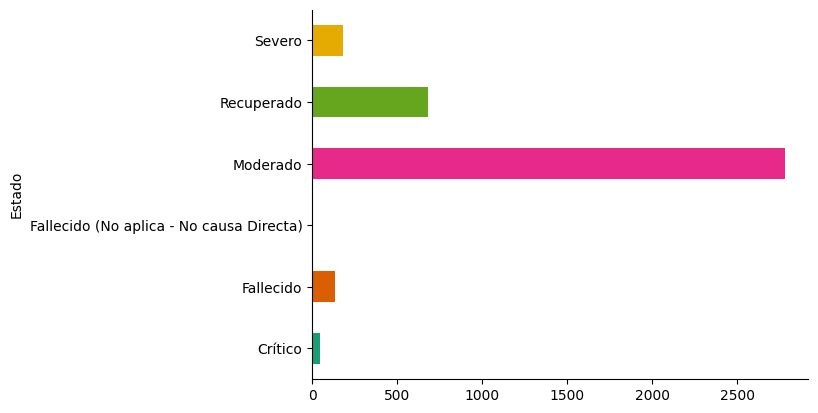

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
data.groupby('Estado').size().plot(kind='barh', color=sns.color_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

**4. DISTRIBUCIÓN DE LOS ESTADOS REPORTADOS VS. LOCALIDAD**

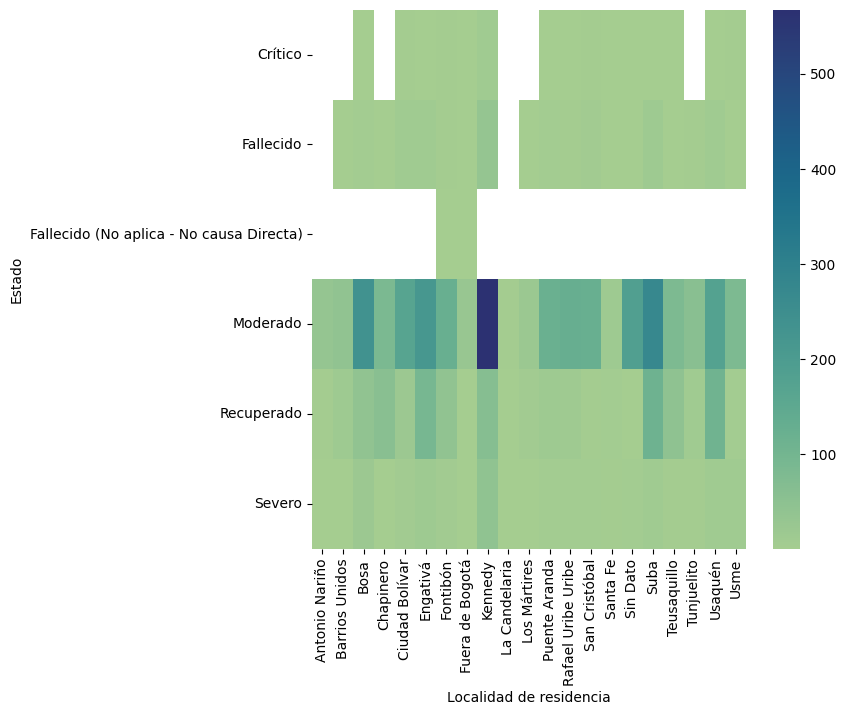

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd

plt.subplots(figsize=(7, 7))

df_2dhist = pd.DataFrame({
    x_label: grp['Estado'].value_counts()
    for x_label, grp in data.groupby('Localidad de residencia')
})

sns.heatmap(df_2dhist, cmap='crest')
plt.xlabel('Localidad de residencia')
_ = plt.ylabel('Estado')

**5. CONVERSIÓN DE LA FECHA DE DIAGNÓSTICO**

In [ ]:
data["Fecha de diagnóstico"] = pd.to_datetime(data["Fecha de diagnóstico"], dayfirst='True').dt.strftime("%Y%m%d") # quita / (ej. 20200410)
data['Fecha de diagnóstico'] = data['Fecha de diagnóstico'].astype('datetime64[ns]') # separa con - (ej. 2020-04-10)
data['Fecha de diagnóstico'] = data['Fecha de diagnóstico'].dt.dayofyear # convierte al día del año (ej. 101)


In [ ]:
data = data.rename(columns={'Fecha de diagnóstico': 'Día de diagnóstico'}) # renombra la columna

data.head(registro)

,Día de diagnóstico,Ciudad de residencia,Localidad de residencia,Edad,Sexo,Tipo de caso,Ubicación,Estado
0,101.0,Bogotá,Usaquén,19,F,Importado,Casa,Recuperado
1,101.0,Bogotá,Engativá,22,F,Importado,Casa,Recuperado
2,101.0,Bogotá,Engativá,28,F,Importado,Casa,Recuperado
3,101.0,Bogotá,Fontibón,36,F,Importado,Casa,Recuperado
4,101.0,Bogotá,Kennedy,42,F,Importado,Casa,Recuperado
...,...,...,...,...,...,...,...,...
3819,128.0,Bogotá,San Cristóbal,42,M,En estudio,Casa,Moderado
3820,128.0,Bogotá,Teusaquillo,36,M,En estudio,Casa,Moderado
3821,128.0,Bogotá,Engativá,56,F,En estudio,Hospital,Severo
3822,129.0,Bogotá,Engativá,33,M,En estudio,Casa,Moderado


**6. DISTRIBUCIÓN TEMPORAL DE LOS ESTADOS**

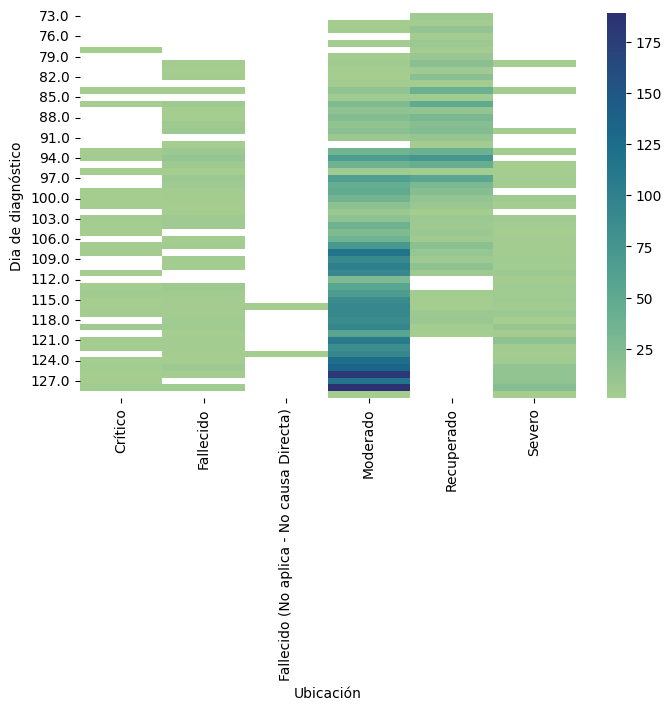

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 5))
df_2dhist = pd.DataFrame({
    x_label: grp['Día de diagnóstico'].value_counts()
    for x_label, grp in data.groupby('Estado')
})
sns.heatmap(df_2dhist, cmap='crest')
plt.xlabel('Ubicación')
_ = plt.ylabel('Dia de diagnóstico')

**7. CASOS DE CONTAGIO POR GÉNERO**

cantidad de contagiados por COVID en Bogotá: 3824
cantidad de hombres contagiados por COVID: 1931 (50.50%)
cantidad de mujeres contagiadas por COVID: 1893 (49.50%)


<Figure size 600x400 with 0 Axes>

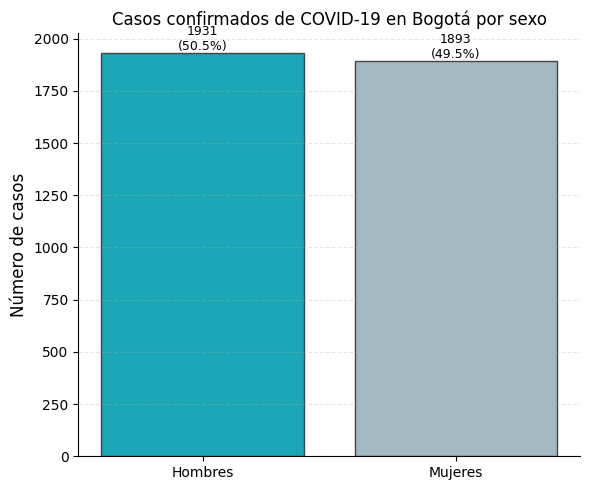

In [ ]:
cantidad_contagiados = len(data)

cantidad_contagiados_M = len(data[data["Sexo"] == "M"])
porc_M = cantidad_contagiados_M * 100 / cantidad_contagiados

cantidad_contagiados_F = len(data[data["Sexo"] == "F"])
porc_F = cantidad_contagiados_F * 100 / cantidad_contagiados

print('cantidad de contagiados por COVID en Bogotá:', cantidad_contagiados)
print('cantidad de hombres contagiados por COVID:', cantidad_contagiados_M,
      f'({porc_M:.2f}%)')
print('cantidad de mujeres contagiadas por COVID:', cantidad_contagiados_F,
      f'({porc_F:.2f}%)')

# ============================
#   Gráfica por sexo
# ============================
plt.figure(figsize=(6,4))

labels = ['Hombres', 'Mujeres']
values = [cantidad_contagiados_M, cantidad_contagiados_F]
porcentajes = [porc_M, porc_F]

plt.figure(figsize=(6,5))
bars = plt.bar(labels, values,
               color=['#1aa6b7', '#a3bac3'],  # turquesa + gris azulado
               edgecolor='#444444')

# Título y etiquetas
plt.title('Casos confirmados de COVID-19 en Bogotá por sexo', fontsize=12)
plt.ylabel('Número de casos', fontsize=12)

# Quitar spines superiores y derecho
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Línea de fondo suave
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Etiquetas encima de cada barra (número y %)
for bar, pct in zip(bars, porcentajes):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f'{int(height)}\n({pct:.1f}%)',
             ha='center', va='bottom',
             fontsize=9)

plt.tight_layout()
plt.show()


**8. CASOS DE CONTAGIO POR DÍA DE DIAGNÓSTICO**

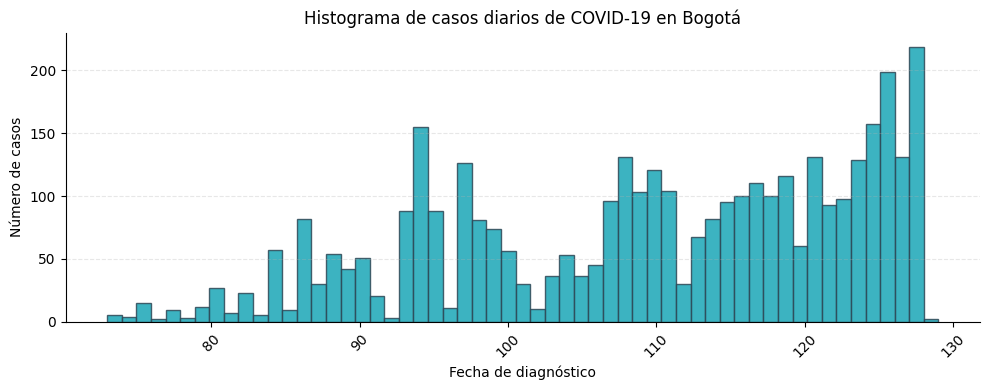

In [ ]:
# Número de días únicos reportados
num_dias = data['Día de diagnóstico'].nunique()

# Histograma estilo "elegante"
plt.figure(figsize=(10,4))
plt.hist(data['Día de diagnóstico'],
         bins=num_dias,
         color='#1aa6b7',        # Turquesa elegante
         edgecolor='#2e4756',   # Gris azul oscuro para delinear
         alpha=0.85)

plt.xlabel('Fecha de diagnóstico', fontsize=10)
plt.ylabel('Número de casos', fontsize=10)
plt.title('Histograma de casos diarios de COVID-19 en Bogotá', fontsize=12)

# Estilo visual más limpio
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

**9. EVOLUCIÓN ACUMULADA DE CASOS DE COVID-19 EN BOGOTÁ**

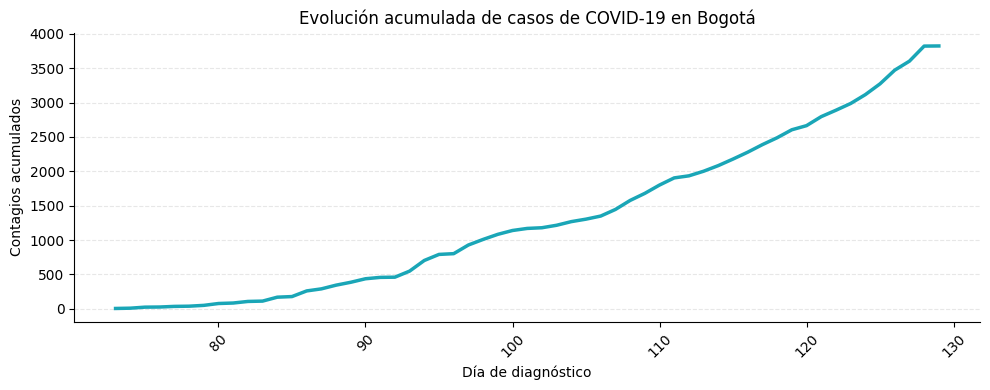

In [ ]:
# Ordenar por fecha
data = data.sort_values('Día de diagnóstico')

# Contar casos diarios
casos_por_dia = data.groupby('Día de diagnóstico').size()

# Calcular los contagios acumulados
acumulado = casos_por_dia.cumsum()

# ============================
# Gráfico de contagios acumulados
# ============================

plt.figure(figsize=(10,4))
plt.plot(acumulado.index, acumulado.values,
         color='#1aa6b7', linewidth=2.5)

plt.xlabel('Día de diagnóstico', fontsize=10)
plt.ylabel('Contagios acumulados', fontsize=10)
plt.title('Evolución acumulada de casos de COVID-19 en Bogotá', fontsize=12)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**10. DISTRIBUCIÓN DE CASOS DE COVID-19 POR EDAD**

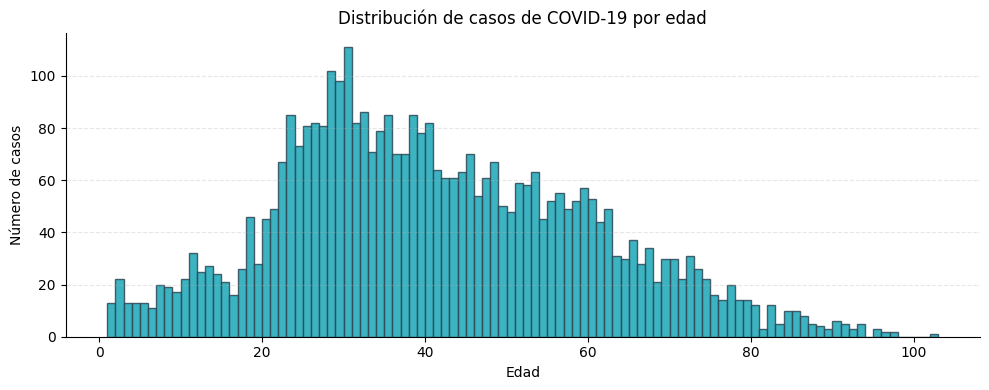

In [ ]:
# Asegurar que la columna Edad sea numérica
data['Edad'] = pd.to_numeric(data['Edad'], errors='coerce')

# Calcular número de bins: uno por cada edad en el rango del dataset
edad_min = int(data['Edad'].min())
edad_max = int(data['Edad'].max())
num_bins = edad_max - edad_min

plt.figure(figsize=(10,4))
plt.hist(
    data['Edad'].dropna(),
    bins=num_bins,
    color='#1aa6b7',       # turquesa
    edgecolor='#2e4756',   # gris oscuro
    alpha=0.85
)

plt.xlabel('Edad', fontsize=10)
plt.ylabel('Número de casos', fontsize=10)
plt.title('Distribución de casos de COVID-19 por edad', fontsize=12)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Definir rangos de edad
bins = [0, 20, 40, 60, 80, 100]
labels = ['0-20', '20-40', '40-60', '60-80', '80-100']

# Crear una nueva columna con el grupo de edad
data['GrupoEdad'] = pd.cut(data['Edad'], bins=bins, labels=labels, right=False)

# Calcular total de casos por grupo
casos_por_grupo = data['GrupoEdad'].value_counts().sort_index()

# Calcular porcentajes
porcentajes = (casos_por_grupo / len(data)) * 100

# Unir resultados en una sola tabla
resultado = pd.DataFrame({
    'Casos': casos_por_grupo,
    'Porcentaje (%)': porcentajes.round(2)
})

print(resultado)

           Casos  Porcentaje (%)
GrupoEdad                       
0-20         408           10.67
20-40       1580           41.32
40-60       1171           30.62
60-80        566           14.80
80-100        98            2.56


**11. DISTRIBUCIÓN DE FALLECIDOS POR COVID-19 SEGÚN EDAD**

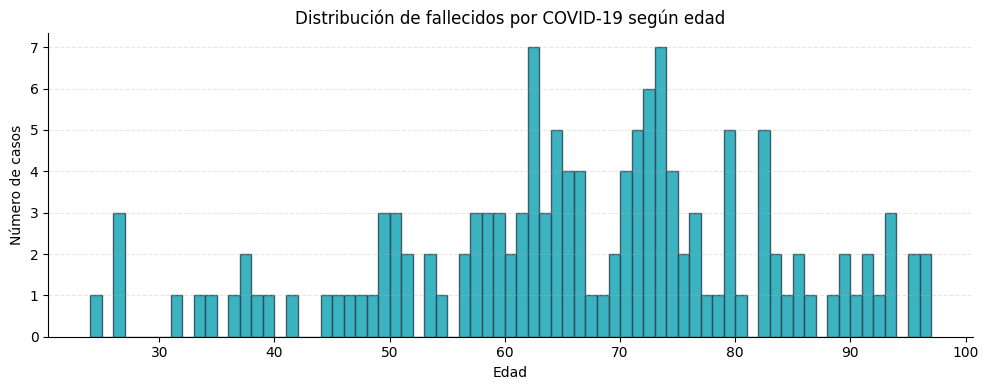

In [ ]:
# Filtrar y crear copia para evitar warnings
fallecidos = data[data['Estado'] == 'Fallecido'].copy()


# Calcular número de bins (no necesariamente es el mismo del grupo completo - todos los estados)
edad_min = int(fallecidos['Edad'].min())
edad_max = int(fallecidos['Edad'].max())
num_bins_fallecidos = edad_max - edad_min

plt.figure(figsize=(10,4))
plt.hist(
    fallecidos['Edad'].dropna(),
    bins=num_bins_fallecidos,
    color='#1aa6b7',
    edgecolor='#2e4756',
    alpha=0.85
)

plt.xlabel('Edad', fontsize=10)
plt.ylabel('Número de casos', fontsize=10)
plt.title('Distribución de fallecidos por COVID-19 según edad', fontsize=12)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# Clasificar en grupos de edad
fallecidos['GrupoEdad'] = pd.cut(
    fallecidos['Edad'],
    bins=bins,
    labels=labels,
    right=False
)

# Calcular cantidad de fallecidos por grupo
fallecidos_por_grupo = fallecidos['GrupoEdad'].value_counts().sort_index()

# Calcular porcentaje respecto al total de fallecidos
porcentajes = (fallecidos_por_grupo / len(fallecidos)) * 100

# Crear tabla final
tabla_fallecidos = pd.DataFrame({
    'Fallecidos': fallecidos_por_grupo,
    'Porcentaje (%)': porcentajes.round(2)
})

print(tabla_fallecidos)

           Fallecidos  Porcentaje (%)
GrupoEdad                            
0-20                0            0.00
20-40              12            8.82
40-60              28           20.59
60-80              70           51.47
80-100             26           19.12


**12. CASOS DE CONTAGIO POR LOCALIDAD Y FALLECIDOS POR LOCALIDAD**

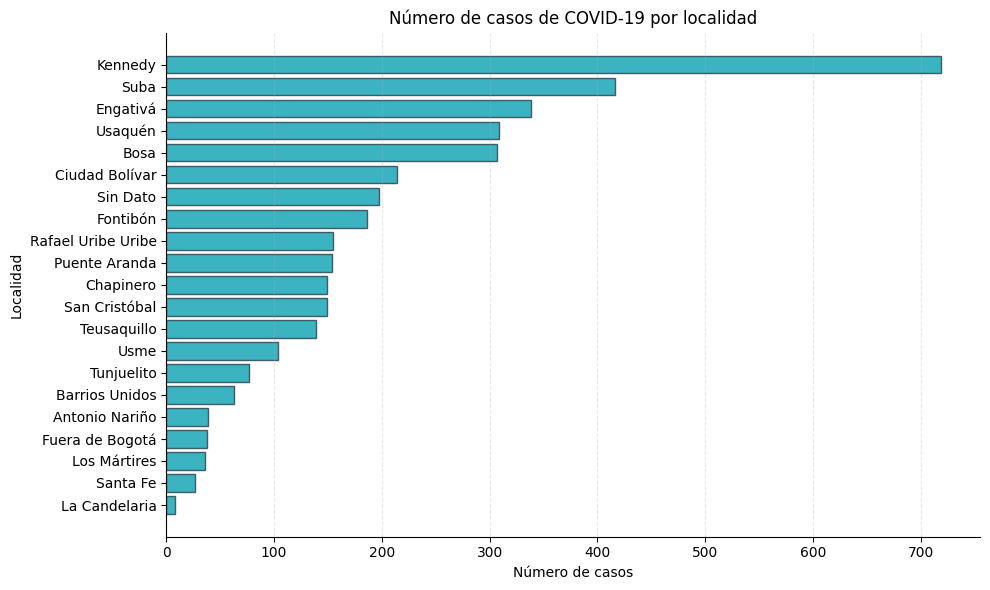

In [ ]:
casos_por_localidad = data['Localidad de residencia'].value_counts().sort_values(ascending=True)

plt.figure(figsize=(10,6))
plt.barh(
    casos_por_localidad.index,
    casos_por_localidad.values,
    color='#1aa6b7',
    edgecolor='#2e4756',
    alpha=0.85
)

plt.xlabel('Número de casos', fontsize=10)
plt.ylabel('Localidad', fontsize=10)
plt.title('Número de casos de COVID-19 por localidad', fontsize=12)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

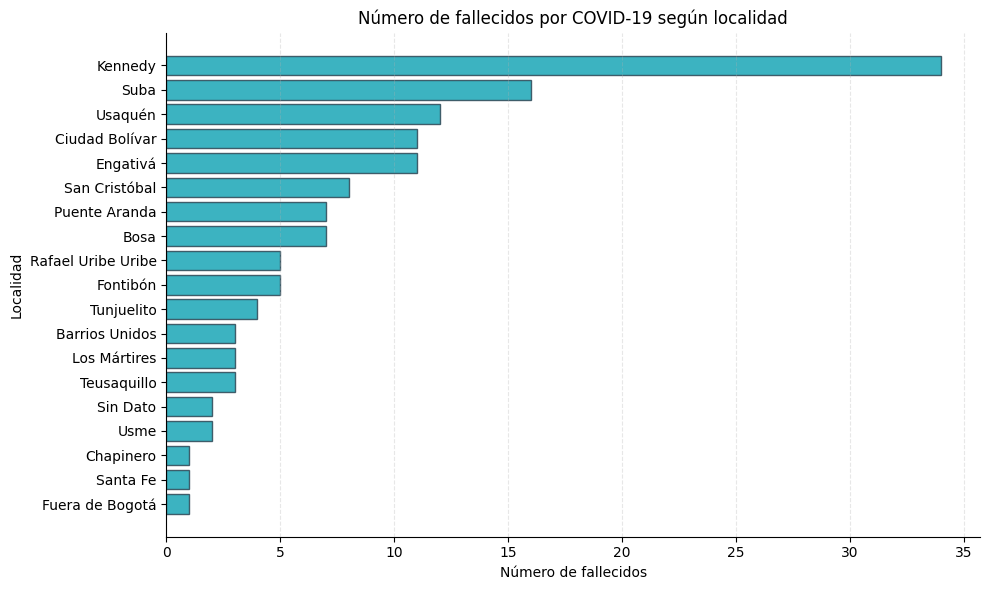

In [ ]:
fallecidos = data[data['Estado'] == 'Fallecido'].copy()

# Contar fallecidos por localidad
fallecidos_por_localidad = fallecidos['Localidad de residencia'].value_counts().sort_values(ascending=True)

# Crear gráfica
plt.figure(figsize=(10,6))
plt.barh(
    fallecidos_por_localidad.index,
    fallecidos_por_localidad.values,
    color='#1aa6b7',       # turquesa
    edgecolor='#2e4756',   # gris oscuro
    alpha=0.85
)

plt.xlabel('Número de fallecidos', fontsize=10)
plt.ylabel('Localidad', fontsize=10)
plt.title('Número de fallecidos por COVID-19 según localidad', fontsize=12)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

**13. TASA DE MUERTE POR LOCALIDAD**

In [ ]:
# 1. Total de contagiados por localidad
contagiados_localidad = data['Localidad de residencia'].value_counts()

# 2. Total de fallecidos por localidad
fallecidos_localidad = data[data['Estado'] == 'Fallecido']['Localidad de residencia'].value_counts()

# 3. Unir ambas series en un solo dataframe
df_tasa = pd.DataFrame({
    'Contagiados': contagiados_localidad,
    'Fallecidos': fallecidos_localidad
})

# 4. Reemplazar NaN (localidades sin fallecidos) por 0
df_tasa = df_tasa.fillna(0)

# 5. Calcular la tasa de muerte
df_tasa['Tasa de muerte (%)'] = (df_tasa['Fallecidos'] / df_tasa['Contagiados']) * 100
df_tasa['Tasa de muerte (%)'] = df_tasa['Tasa de muerte (%)'].round(2)

# 6. Ordenar de menor a mayor tasa
df_tasa = df_tasa.sort_values(by='Tasa de muerte (%)')

print(df_tasa)

                         Contagiados  Fallecidos  Tasa de muerte (%)
Localidad de residencia                                             
Antonio Nariño                    39         0.0                0.00
La Candelaria                      8         0.0                0.00
Chapinero                        149         1.0                0.67
Sin Dato                         197         2.0                1.02
Usme                             104         2.0                1.92
Teusaquillo                      139         3.0                2.16
Bosa                             307         7.0                2.28
Fuera de Bogotá                   38         1.0                2.63
Fontibón                         186         5.0                2.69
Rafael Uribe Uribe               155         5.0                3.23
Engativá                         338        11.0                3.25
Santa Fe                          27         1.0                3.70
Suba                             4

Libro: Investigación en Ciencia de Datos

---


Versión: 2026 – Material complementario para Google Colab.